In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from benchmark.examples.gaussian.datasets.datasets import GetDatasets 

In [5]:
RNG=np.random.default_rng(2025)
num_dims=5
num_obs=50
likelihood_std=1
student_df=5

In [ ]:
# generate observation datasets
# 1.mu=0,normal  2. mu=5, noraml 3. mu=0,student_t,df=3
df_m1=GetDatasets(obs_mu_prior_mean=0, obs_mu_prior_std=1,
               num_dims=num_dims, num_obs=num_obs, obs_likelihood_std=likelihood_std, 
               num_datasets=50,rng=RNG)
df_m2=GetDatasets(obs_mu_prior_mean=5, obs_mu_prior_std=1,
               num_dims=num_dims, num_obs=num_obs, obs_likelihood_std=likelihood_std, 
               num_datasets=50,rng=RNG)
df_m3=GetDatasets(obs_mu_prior_mean=0, obs_mu_prior_std=1,
               num_dims=num_dims, num_obs=num_obs, obs_likelihood_std=likelihood_std,
               num_datasets=50,rng=RNG)
datasets_m1=df_m1.get_datasets_normal()
datasets_m2=df_m2.get_datasets_normal()
datasets_m3=df_m3.get_datasets_student_t(df=student_df)


In [6]:
import pickle
# read observation datasets
def load_pickle(path: str):
    with open(path, "rb") as f:
        return pickle.load(f)

datasets_m1  = load_pickle("/Users/mandyking/benchmark/benchmark/examples/gaussian/results/datasets/m1.pkl")
datasets_m2 = load_pickle("/Users/mandyking/benchmark/benchmark/examples/gaussian/results/datasets/m2.pkl")
datasets_m3   = load_pickle("/Users/mandyking/benchmark/benchmark/examples/gaussian/results/datasets/m3.pkl")

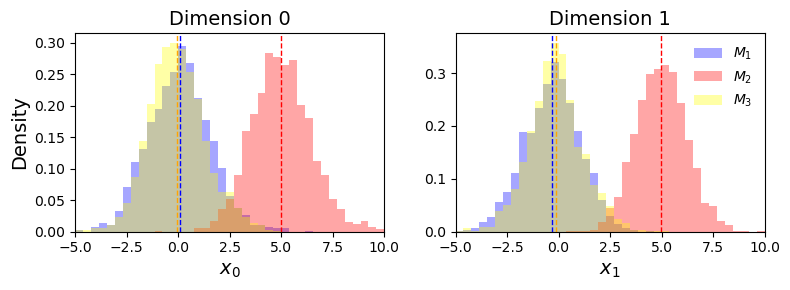

In [16]:
import numpy as np
import matplotlib.pyplot as plt


def collect_dim(datasets, key, dim):
    return np.concatenate([
        np.asarray(d[key])[:, dim]
        for d in datasets
    ])


def plot_observation_distributions(datasets_m1, datasets_m2, datasets_m3, num_dims):
    D = 2

    fig, axes = plt.subplots(1, D, figsize=(4 * D, 3), sharey=False)

    x_min, x_max = -5, 10
    bins = np.linspace(x_min, x_max, 40)

    for dim in range(D):
        ax = axes[dim] if D > 1 else axes

        normal_vals_0 = collect_dim(datasets_m1, key="x", dim=dim)
        normal_vals_10 = collect_dim(datasets_m2, key="x", dim=dim)
        student_vals = collect_dim(datasets_m3, key="x", dim=dim)

        # ===== Histogram =====
        ax.hist(normal_vals_0, bins=bins, density=True,
                alpha=0.35, color="blue", label=r"$M_1$")

        ax.hist(normal_vals_10, bins=bins, density=True,
                alpha=0.35, color="red", label=r"$M_2$")

        ax.hist(student_vals, bins=bins, density=True,
                alpha=0.35, color="yellow", label=r"$M_3$")

        # ===== Mean lines =====
        ax.axvline(normal_vals_0.mean(), linestyle="--", linewidth=1, color="blue")
        ax.axvline(normal_vals_10.mean(), linestyle="--", linewidth=1, color="red")
        ax.axvline(student_vals.mean(), linestyle="--", linewidth=1, color="orange")

        # ===== 统一坐标轴 =====
        ax.set_xlim(x_min, x_max)

        ax.set_title(f"Dimension {dim}",fontsize=14)
        ax.set_xlabel(rf"$x_{dim}$",fontsize=14)

        if dim == 0:
            ax.set_ylabel("Density",fontsize=14)

    axes[-1].legend(frameon=False)

    plt.tight_layout()
    plt.show()


plot_observation_distributions(datasets_m1, datasets_m2, datasets_m3, num_dims)

In [12]:
from scipy.stats import wasserstein_distance

for dim in range(num_dims):
    m1 = collect_dim(datasets_m1, "x", dim)
    m2 = collect_dim(datasets_m2, "x", dim)
    m3 = collect_dim(datasets_m3, "x", dim)

    print(f"Dim {dim}:")
    print("M1 vs M2:", wasserstein_distance(m1, m2))
    print("M1 vs M3:", wasserstein_distance(m1, m3))
    print("M2 vs M3:", wasserstein_distance(m2, m3))
    print()

Dim 0:
M1 vs M2: 4.93366996
M1 vs M3: 0.17984263999999994
M2 vs M3: 5.056601560000001

Dim 1:
M1 vs M2: 5.29155976
M1 vs M3: 0.17736691999999962
M2 vs M3: 5.1256362

Dim 2:
M1 vs M2: 4.84487
M1 vs M3: 0.21510712000000004
M2 vs M3: 4.99179432

Dim 3:
M1 vs M2: 4.887400959999999
M1 vs M3: 0.23625536
M2 vs M3: 5.11432576

Dim 4:
M1 vs M2: 5.27221532
M1 vs M3: 0.19314811999999998
M2 vs M3: 5.395117920000001



In [ ]:
# compare NPE posterior samples distribution
import matplotlib.pyplot as plt

D = 5
fig, axes = plt.subplots(1, D, figsize=(4*D, 3), sharey=False)

for dim in range(D):
    ax = axes[dim]

    normal_vals  = collect_dim(datasets_m1, key="npe_post_samples_m1",dim=dim)
    student_vals = collect_dim(datasets_m3, key="npe_post_samples_m1",dim=dim)
    
    ax.hist(
        normal_vals,
        bins=40,
        density=True,
        alpha=0.6,
        label="normal_0"
    )
    ax.hist(
        student_vals,
        bins=40,
        density=True,
        alpha=0.6,
        label="student_t"
    )

    # posterior mean
    ax.axvline(normal_vals.mean(),  linestyle="--", linewidth=1)
    ax.axvline(student_vals.mean(), linestyle="--", linewidth=1)

    ax.set_title(f"NPE Posterior – dim {dim}")
    ax.set_xlabel(rf"$\mu_{dim}$")

    if dim == 0:
        ax.set_ylabel("Density")

axes[-1].legend(frameon=False)

plt.tight_layout()
plt.show()


In [ ]:
# compare analytical posterior samples distribution
import matplotlib.pyplot as plt

D = 5
fig, axes = plt.subplots(1, D, figsize=(4*D, 3), sharey=False)

for dim in range(D):
    ax = axes[dim]

    normal_vals  = collect_dim(datasets_m1, key="gold_post_samples_m1",dim=dim)
    student_vals = collect_dim(datasets_m3, key="gold_post_samples_m1",dim=dim)
    
    ax.hist(
        normal_vals,
        bins=40,
        density=True,
        alpha=0.6,
        label="normal_0"
    )
    ax.hist(
        student_vals,
        bins=40,
        density=True,
        alpha=0.6,
        label="student_t"
    )

    # posterior mean
    ax.axvline(normal_vals.mean(),  linestyle="--", linewidth=1)
    ax.axvline(student_vals.mean(), linestyle="--", linewidth=1)

    ax.set_title(f"Gold Posterior – dim {dim}")
    ax.set_xlabel(rf"$\mu_{dim}$")

    if dim == 0:
        ax.set_ylabel("Density")

axes[-1].legend(frameon=False)

plt.tight_layout()
plt.show()


In [ ]:
from bayesflow.metrics import MaximumMeanDiscrepancy
import tensorflow as tf
from scipy.stats import kurtosis

obs_normal=[np.asarray(d['obs_data']) for d in datasets_normal_0]
obs_student=[np.asarray(d['obs_data']) for d in datasets_student]
mmd=MaximumMeanDiscrepancy(kernel='gaussian')
MMD_list=[]
for i in range(len(obs_normal)):
    X=tf.convert_to_tensor(obs_normal[i],dtype=np.float32)
    Y=tf.convert_to_tensor(obs_student[i],dtype=np.float32)
    MMD=float(mmd(X,Y))
    MMD_list.append(MMD)
    
plt.figure()
plt.boxplot(MMD_list, showmeans=True)
plt.ylabel("MMD ")
plt.title("Observation MMD (normal vs. t(df=10))")
plt.tight_layout()
plt.show()

kurt_normal = kurtosis(obs_normal, axis=1, fisher=True)   # Shape: (50, 5)
kurt_student = kurtosis(obs_student, axis=1, fisher=True) # Shape: (50, 5)
mean_kurt_normal = np.mean(kurt_normal, axis=1) # Shape: (50,)
mean_kurt_student = np.mean(kurt_student, axis=1) # Shape: (50,)
print("Normal Group Mean Kurtosis (First 5):", mean_kurt_normal[:5])
print("Student Group Mean Kurtosis (First 5):", mean_kurt_student[:5])

In [ ]:
def summarize_obs(obs):
    """
    obs: array of shape (n_obs, D)
    return: feature vector of shape (2*D,)
    """
    mean = obs.mean(axis=0)
    std  = obs.std(axis=0)
    return np.concatenate([mean, std])
# normal_0
X_normal = np.array([
    summarize_obs(np.asarray(d["obs_data"]))
    for d in datasets_normal_0
])

# student_t
X_student = np.array([
    summarize_obs(np.asarray(d["obs_data"]))
    for d in datasets_student
])

X = np.vstack([X_normal, X_student])
y = np.array([0]*len(X_normal) + [1]*len(X_student))

In [ ]:
def summarize_mean_only(obs):
    obs = np.asarray(obs, dtype=float)
    return obs.mean(axis=0)

X_normal = np.array([summarize_mean_only(d["obs_data"]) for d in datasets_normal_0])
X_student = np.array([summarize_mean_only(d["obs_data"]) for d in datasets_student])
X = np.vstack([X_normal, X_student])
y = np.array([0]*len(X_normal) + [1]*len(X_student))

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold

clf = LogisticRegression(max_iter=500)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
aucs = []

for train, test in cv.split(X, y):
    clf.fit(X[train], y[train])
    probs = clf.predict_proba(X[test])[:, 1]
    aucs.append(roc_auc_score(y[test], probs))

print("AUC (mean ± sd):", np.mean(aucs), np.std(aucs))


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

normal_vals = np.array([d["npe_log_marginal"] for d in datasets_normal_0], dtype=float)
student_vals = np.array([d["npe_log_marginal"] for d in datasets_student], dtype=float)

plt.figure(figsize=(6,4))
plt.hist(normal_vals, bins=30, alpha=0.6, density=True, label="normal_0")
plt.hist(student_vals, bins=30, alpha=0.6, density=True, label="student_t")
plt.xlabel("NPE log_marginal")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:

normal_vals = np.array([d["gold_log_marginal"] for d in datasets_normal_0], dtype=float)
student_vals = np.array([d["gold_log_marginal"] for d in datasets_student], dtype=float)

plt.figure(figsize=(6,4))
plt.hist(normal_vals, bins=30, alpha=0.6, density=True, label="normal_0")
plt.hist(student_vals, bins=30, alpha=0.6, density=True, label="student_t")
plt.xlabel("Gold log_marginal")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
print(datasets_normal_0[3]['gold_log_marginal'])
print(datasets_normal_02[3]['gold_log_marginal'])